In [1]:
from pathlib import Path
import json
import random
import copy
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
import scipy.sparse as sp

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import scgpt

from scgpt.model import TransformerModel
from scgpt.tokenizer import GeneVocab, tokenize_and_pad_batch
from scgpt.preprocess import Preprocessor

/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
MODEL_DIR = Path("../models")

FINETUNE_DIR = MODEL_DIR / "scGPT_finetuned"
FINETUNE_DIR.mkdir(parents=True, exist_ok=True)

# Model checkpoint from notebook01
SCGPT_MODEL_DIR = MODEL_DIR / "scGPT_human"

vocab_file = SCGPT_MODEL_DIR / "vocab.json"
config_file = SCGPT_MODEL_DIR / "args.json"
model_file = SCGPT_MODEL_DIR / "best_model.pt"

# Fine-tuning parameters
N_BINS = 51

# Reduced from official 3001 to make training practical on a Mac.
# Most cells should still retain a large fraction of expressed HVGs.
MAX_SEQ_LEN = 1024

BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16

LEARNING_RATE = 1e-4
EPOCHS = 5
PATIENCE = 2

# Fine-tune classifier + last N transformer layers.
N_UNFROZEN_LAYERS = 2

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("scGPT:", scgpt.__version__)
print("Device:", device)

PyTorch: 2.3.0
scGPT: 0.2.4
Device: mps


In [4]:
#Load dono splites from notebook01
adata_train = sc.read_h5ad(
    DATA_DIR / "train_raw.h5ad"
)

adata_val = sc.read_h5ad(
    DATA_DIR / "val_raw.h5ad"
)

adata_test = sc.read_h5ad(
    DATA_DIR / "test_raw.h5ad"
)

print("Train:", adata_train.shape)
print("Val:  ", adata_val.shape)
print("Test: ", adata_test.shape)

Train: (32252, 20889)
Val:   (10866, 20889)
Test:  (15217, 20889)


In [5]:
#Load HVG's
with open(
    RESULTS_DIR / "baseline_hvg_ids.json"
) as f:
    hvg_ids = json.load(f)

print("Stored training HVGs:", len(hvg_ids))

Stored training HVGs: 2000


In [6]:
#All HVG's shared across splits
shared_hvgs = [
    g for g in hvg_ids
    if (
        g in adata_train.var_names
        and g in adata_val.var_names
        and g in adata_test.var_names
    )
]

print("Shared HVGs:", len(shared_hvgs))

Shared HVGs: 2000


In [7]:
#subset data
adata_train = adata_train[:, shared_hvgs].copy()
adata_val = adata_val[:, shared_hvgs].copy()
adata_test = adata_test[:, shared_hvgs].copy()

print(adata_train.shape)

(32252, 2000)


In [8]:
#Load Gene Vocabulary
vocab = GeneVocab.from_file(vocab_file)

special_tokens = [
    "<pad>",
    "<cls>",
    "<eoc>",
]

for token in special_tokens:
    if token not in vocab:
        vocab.append_token(token)

vocab.set_default_index(
    vocab["<pad>"]
)

print("Vocabulary size:", len(vocab))



Vocabulary size: 60697


In [9]:
#Double check gene_name is correct to match vocab of scGPT
adata_train.var[
    ["gene_name"]
].head()

,gene_name
feature_id,
ENSG00000188290,HES4
ENSG00000187608,ISG15
ENSG00000186891,TNFRSF18
ENSG00000186827,TNFRSF4
ENSG00000187730,GABRD


In [10]:
#Check how many of the top 2000 genes match with scGPT
gene_names = (
    adata_train.var["gene_name"]
    .astype(str)
)

in_vocab = np.array([
    gene in vocab
    for gene in gene_names
])

print(
    f"Genes matched to scGPT vocabulary: "
    f"{in_vocab.sum()} / {len(in_vocab)} "
    f"({100 * in_vocab.mean():.1f}%)"
)

Genes matched to scGPT vocabulary: 1468 / 2000 (73.4%)


In [11]:
#Remove non-matching genes
matched_var_names = (
    adata_train.var_names[in_vocab]
    .tolist()
)

adata_train = adata_train[
    :,
    matched_var_names
].copy()

adata_val = adata_val[
    :,
    matched_var_names
].copy()

adata_test = adata_test[
    :,
    matched_var_names
].copy()

In [14]:
#Remove possible duplicate gene symbols
gene_names = (
    adata_train.var["gene_name"]
    .astype(str)
)

keep_unique = ~gene_names.duplicated()

unique_var_names = (
    adata_train.var_names[keep_unique]
    .tolist()
)

adata_train = adata_train[
    :,
    unique_var_names
].copy()

adata_val = adata_val[
    :,
    unique_var_names
].copy()

adata_test = adata_test[
    :,
    unique_var_names
].copy()

print("Final genes:", adata_train.n_vars)

Final genes: 1468


In [17]:
#Using the 8 cell types from the baseline
if hasattr(
    adata_train.obs["cell_type"],
    "cat"
):
    celltypes = list(
        adata_train.obs[
            "cell_type"
        ].cat.categories
    )
else:
    celltypes = sorted(
        adata_train.obs[
            "cell_type"
        ].astype(str).unique()
    )

celltypes

['monocyte',
 'CD8-positive, alpha-beta T cell',
 'CD4-positive, alpha-beta T cell',
 'B cell',
 'natural killer cell',
 'alpha-beta T cell',
 'dendritic cell',
 'platelet']

In [18]:
#Create mappings
type2id = {
    cell_type: i
    for i, cell_type in enumerate(celltypes)
}

id2type = {
    i: cell_type
    for cell_type, i in type2id.items()
}

num_types = len(celltypes)

print("Number of cell types:", num_types)

for i, cell_type in id2type.items():
    print(i, cell_type)

Number of cell types: 8
0 monocyte
1 CD8-positive, alpha-beta T cell
2 CD4-positive, alpha-beta T cell
3 B cell
4 natural killer cell
5 alpha-beta T cell
6 dendritic cell
7 platelet


In [19]:
#apply mappings to the data
for adata_split in [
    adata_train,
    adata_val,
    adata_test,
]:

    labels = (
        adata_split.obs["cell_type"]
        .astype(str)
    )

    assert labels.isin(type2id).all()

    adata_split.obs["celltype_id"] = (
        labels.map(type2id).astype(int)
    )

In [20]:
#save mappings
with open(
    FINETUNE_DIR / "celltype_mapping.json",
    "w",
) as f:
    json.dump(
        {
            "type2id": type2id,
            "id2type": id2type,
        },
        f,
        indent=2,
    )

In [21]:
#setting up preprocessor
preprocessor = Preprocessor(
    use_key="X",

    # Already QC-filtered on Day 1
    filter_gene_by_counts=False,
    filter_cell_by_counts=False,

    normalize_total=1e4,
    result_normed_key="X_normed",

    # Our saved input is raw counts
    log1p=True,
    result_log1p_key="X_log1p",

    # Already chose HVGs from TRAIN only
    subset_hvg=False,

    binning=N_BINS,
    result_binned_key="X_binned",
)

In [22]:
#Preprocessing data split
print("Preprocessing training set...")
preprocessor(
    adata_train,
    batch_key=None,
)

print("Preprocessing validation set...")
preprocessor(
    adata_val,
    batch_key=None,
)

print("Preprocessing test set...")
preprocessor(
    adata_test,
    batch_key=None,
)

print("Preprocessing complete.")

Preprocessing training set...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Preprocessing validation set...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Preprocessing test set...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Preprocessing complete.


In [71]:
#Creating gene token id's
genes = (
    adata_train.var["gene_name"]
    .astype(str)
    .tolist()
)

gene_ids = np.array(
    vocab(genes),
    dtype=int,
)

print("Number of genes:", len(genes))
print("Number of gene IDs:", len(gene_ids))
print("First genes:", genes[:5])
print("First IDs:", gene_ids[:5])

Matched genes: 1468 / 1468


In [25]:
#convert data to a binned matrix
def get_binned_matrix(adata):
    X = adata.layers["X_binned"]

    if sp.issparse(X):
        X = X.toarray()

    return np.asarray(X)

train_counts = get_binned_matrix(
    adata_train
)

val_counts = get_binned_matrix(
    adata_val
)

test_counts = get_binned_matrix(
    adata_test
)

In [27]:
#set padding value
PAD_TOKEN = "<pad>"
PAD_VALUE = -2

#Tokenize the genes for each split
tokenized_train = tokenize_and_pad_batch(
    train_counts,
    gene_ids,
    max_len=MAX_SEQ_LEN, #low length compared to tutorial to compensate for working on a mac
    vocab=vocab,
    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,
    append_cls=True,
    include_zero_gene=False,
)

tokenized_val = tokenize_and_pad_batch(
    val_counts,
    gene_ids,
    max_len=MAX_SEQ_LEN,
    vocab=vocab,
    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,
    append_cls=True,
    include_zero_gene=False,
)

tokenized_test = tokenize_and_pad_batch(
    test_counts,
    gene_ids,
    max_len=MAX_SEQ_LEN,
    vocab=vocab,
    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,
    append_cls=True,
    include_zero_gene=False,
)

#Delete dense matrices
del train_counts
del val_counts
del test_counts

gc.collect()

In [30]:
#Cell Dataset class definition
class CellDataset(Dataset):

    def __init__(
        self,
        tokenized,
        labels,
    ):
        self.genes = tokenized["genes"]
        self.values = tokenized["values"]

        self.labels = torch.tensor(
            labels,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "gene_ids": self.genes[idx],
            "values": self.values[idx],
            "labels": self.labels[idx],
        }

#Get labels
y_train = (
    adata_train.obs["celltype_id"]
    .to_numpy(dtype=int)
)

y_val = (
    adata_val.obs["celltype_id"]
    .to_numpy(dtype=int)
)

y_test = (
    adata_test.obs["celltype_id"]
    .to_numpy(dtype=int)
)



#Create datasets
train_dataset = CellDataset(
    tokenized_train,
    y_train,
)

val_dataset = CellDataset(
    tokenized_val,
    y_val,
)

test_dataset = CellDataset(
    tokenized_test,
    y_test,
)




#Set up dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [31]:
#Get scGPT model
with open(config_file) as f:
    model_config = json.load(f)

model_config

{'data_source': '/scratch/ssd004/datasets/cellxgene/scb_strict/human',
 'save_dir': '/scratch/ssd004/datasets/cellxgene/save/cellxgene_census_human-May23-08-36-2023',
 'load_model': None,
 'n_hvg': None,
 'valid_size_or_ratio': 0.003,
 'dist_backend': 'nccl',
 'grad_accu_steps': 1,
 'pad_token': '<pad>',
 'input_style': 'binned',
 'input_emb_style': 'continuous',
 'n_bins': 51,
 'max_seq_len': 1200,
 'training_tasks': 'both',
 'dist_url': 'tcp://gpu188.cluster.local:53833',
 'mask_ratio': [0.25, 0.5, 0.75],
 'trunc_by_sample': True,
 'vocab_path': '/scratch/ssd004/datasets/cellxgene/scFormer/scformer/tokenizer/default_census_vocab.json',
 'rank': 0,
 'batch_size': 32,
 'eval_batch_size': 64,
 'epochs': 6,
 'lr': 0.0001,
 'scheduler_interval': 100,
 'scheduler_factor': 0.99,
 'warmup_ratio_or_step': 10000.0,
 'no_cls': True,
 'no_cce': True,
 'fp16': True,
 'fast_transformer': True,
 'nlayers': 12,
 'nheads': 8,
 'embsize': 512,
 'd_hid': 512,
 'dropout': 0.2,
 'n_layers_cls': 3,
 'log_

In [32]:
#Check the architecture
embsize = model_config["embsize"]
nhead = model_config["nheads"]
d_hid = model_config["d_hid"]
nlayers = model_config["nlayers"]
n_layers_cls = model_config["n_layers_cls"]
dropout = model_config["dropout"]

print(
    embsize,
    nhead,
    d_hid,
    nlayers,
    n_layers_cls,
    dropout,
)

512 8 512 12 3 0.2


In [38]:
#Construct model
from scgpt.utils import load_pretrained

model = TransformerModel(
    ntoken=len(vocab),
    d_model=embsize,
    nhead=nhead,
    d_hid=d_hid,
    nlayers=nlayers,

    nlayers_cls=n_layers_cls,
    n_cls=num_types,

    vocab=vocab,
    dropout=dropout,

    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,

    do_mvc=False,
    do_dab=False,

    use_batch_labels=False,
    num_batch_labels=None,

    domain_spec_batchnorm=False,

    input_emb_style="continuous",
    n_input_bins=N_BINS,

    cell_emb_style="cls",

    mvc_decoder_style="inner product",

    ecs_threshold=0.0,
    explicit_zero_prob=False,

    use_fast_transformer=False,
    pre_norm=False,
)

In [39]:
pretrained_dict = torch.load(
    model_file,
    map_location="cpu",
    weights_only=False,
)

model = load_pretrained(
    model,
    pretrained_dict,
    verbose=True,
)

scGPT - INFO - Loading parameter encoder.embedding.weight with shape torch.Size([60697, 512])
scGPT - INFO - Loading parameter encoder.enc_norm.weight with shape torch.Size([512])
scGPT - INFO - Loading parameter encoder.enc_norm.bias with shape torch.Size([512])
scGPT - INFO - Loading parameter value_encoder.linear1.weight with shape torch.Size([512, 1])
scGPT - INFO - Loading parameter value_encoder.linear1.bias with shape torch.Size([512])
scGPT - INFO - Loading parameter value_encoder.linear2.weight with shape torch.Size([512, 512])
scGPT - INFO - Loading parameter value_encoder.linear2.bias with shape torch.Size([512])
scGPT - INFO - Loading parameter value_encoder.norm.weight with shape torch.Size([512])
scGPT - INFO - Loading parameter value_encoder.norm.bias with shape torch.Size([512])
scGPT - INFO - Loading parameter transformer_encoder.layers.0.self_attn.in_proj_weight with shape torch.Size([1536, 512])
scGPT - INFO - Loading parameter transformer_encoder.layers.0.self_attn.

In [40]:
# Freeze every parameter first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the cell-type classification head
for param in model.cls_decoder.parameters():
    param.requires_grad = True

# Unfreeze the final N transformer layers
for layer in model.transformer_encoder.layers[-N_UNFROZEN_LAYERS:]:
    for param in layer.parameters():
        param.requires_grad = True

In [41]:
#Check the percent of the model that will be fine-tuned
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable fraction:   "
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters:     51,335,689
Trainable parameters: 3,687,432
Trainable fraction:   7.18%


In [42]:
#Checking the trainable layers
print("\nTrainable parameter groups:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, tuple(param.shape))


Trainable parameter groups:
transformer_encoder.layers.10.self_attn.in_proj_weight (1536, 512)
transformer_encoder.layers.10.self_attn.in_proj_bias (1536,)
transformer_encoder.layers.10.self_attn.out_proj.weight (512, 512)
transformer_encoder.layers.10.self_attn.out_proj.bias (512,)
transformer_encoder.layers.10.linear1.weight (512, 512)
transformer_encoder.layers.10.linear1.bias (512,)
transformer_encoder.layers.10.linear2.weight (512, 512)
transformer_encoder.layers.10.linear2.bias (512,)
transformer_encoder.layers.10.norm1.weight (512,)
transformer_encoder.layers.10.norm1.bias (512,)
transformer_encoder.layers.10.norm2.weight (512,)
transformer_encoder.layers.10.norm2.bias (512,)
transformer_encoder.layers.11.self_attn.in_proj_weight (1536, 512)
transformer_encoder.layers.11.self_attn.in_proj_bias (1536,)
transformer_encoder.layers.11.self_attn.out_proj.weight (512, 512)
transformer_encoder.layers.11.self_attn.out_proj.bias (512,)
transformer_encoder.layers.11.linear1.weight (512, 

In [43]:
#Using mps
model = model.to(device)

print("Model device:",
      next(model.parameters()).device)

Model device: mps:0


In [44]:
#computing balanced class weights from training data to compensate for unbalanced cell counts
class_counts = np.bincount(
    y_train,
    minlength=num_types,
)

class_weights = (
    len(y_train)
    /
    (num_types * class_counts)
)

class_weight_df = pd.DataFrame({
    "cell_type": [
        id2type[i]
        for i in range(num_types)
    ],
    "n_train": class_counts,
    "weight": class_weights,
})

class_weight_df

,cell_type,n_train,weight
0,monocyte,16790,0.240113
1,"CD8-positive, alpha-beta T cell",3980,1.012940
2,"CD4-positive, alpha-beta T cell",3556,1.133718
3,B cell,3541,1.138520
4,natural killer cell,2278,1.769754
5,alpha-beta T cell,848,4.754127
6,dendritic cell,608,6.630757
7,platelet,651,6.192780


In [45]:
#convert to tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

#define loss as cross entropy loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

In [46]:
#Adam's optimization
optimizer = torch.optim.Adam(
    [
        p
        for p in model.parameters()
        if p.requires_grad
    ],
    lr=LEARNING_RATE,
)

#small learning rate
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1,
    gamma=0.9,
)

#padding token ID
PAD_ID = vocab[PAD_TOKEN]

print("Padding token ID:", PAD_ID)

Padding token ID: 60694


In [47]:
#Training function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):

    #initializing variables and model
    model.train()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    for batch_idx, batch in enumerate(loader):

        gene_ids_batch = (
            batch["gene_ids"]
            .to(device)
        )

        values_batch = (
            batch["values"]
            .to(device)
        )

        labels_batch = (
            batch["labels"]
            .to(device)
        )

        # Tell the transformer which positions are padding
        padding_mask = (
            gene_ids_batch == PAD_ID
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward pass through scGPT
        output = model(
            gene_ids_batch,
            values_batch,
            src_key_padding_mask=padding_mask,
            batch_labels=None,

            CLS=True,
            CCE=False,
            MVC=False,
            ECS=False,

            do_sample=False,
        )

        logits = output["cls_output"]

        # Cell-type classification loss
        loss = criterion(
            logits,
            labels_batch,
        )

        # Backpropagation
        loss.backward()

        # Prevent unstable gradient explosions
        torch.nn.utils.clip_grad_norm_(
            [
                p
                for p in model.parameters()
                if p.requires_grad
            ],
            max_norm=1.0,
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * labels_batch.size(0)
        )

        predictions = (
            logits.argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
        )

        all_labels.extend(
            labels_batch
            .detach()
            .cpu()
            .numpy()
        )

        # Progress output
        if (
            batch_idx % 250 == 0
            and batch_idx > 0
        ):
            print(
                f"Batch "
                f"{batch_idx:4d}/"
                f"{len(loader)} | "
                f"loss={loss.item():.4f}"
            )

    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "macro_f1": epoch_macro_f1,
    }

In [48]:
#evaluation function
def evaluate_model(
    model,
    loader,
    criterion,
    device,
):

    model.eval()

    total_loss = 0.0

    predictions = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            gene_ids_batch = (
                batch["gene_ids"]
                .to(device)
            )

            values_batch = (
                batch["values"]
                .to(device)
            )

            labels_batch = (
                batch["labels"]
                .to(device)
            )

            padding_mask = (
                gene_ids_batch == PAD_ID
            )

            output = model(
                gene_ids_batch,
                values_batch,
                src_key_padding_mask=padding_mask,
                batch_labels=None,

                CLS=True,
                CCE=False,
                MVC=False,
                ECS=False,

                do_sample=False,
            )

            logits = output["cls_output"]

            loss = criterion(
                logits,
                labels_batch,
            )

            total_loss += (
                loss.item()
                * labels_batch.size(0)
            )

            predictions.extend(
                logits.argmax(dim=1)
                .cpu()
                .numpy()
            )

            labels.extend(
                labels_batch
                .cpu()
                .numpy()
            )

    predictions = np.asarray(
        predictions
    )

    labels = np.asarray(
        labels
    )

    metrics = {
        "loss":
            total_loss / len(loader.dataset),

        "accuracy":
            accuracy_score(
                labels,
                predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions,
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                labels,
                predictions,
                average="weighted",
            ),
    }

    return (
        predictions,
        labels,
        metrics,
    )

In [50]:
#TRAIN MODEL (Starting with 5 epochs)
history = []

best_val_f1 = -np.inf
best_state = None
best_epoch = None

epochs_without_improvement = 0

# Disable PyTorch Transformer/MHA inference fastpath.
# The fastpath uses NestedTensor operations that are not implemented on MPS.
torch.backends.mha.set_fastpath_enabled(False)

print(
    "MHA fastpath enabled:",
    torch.backends.mha.get_fastpath_enabled()
)


#Disable nested tensor transformation in scGPT encoder
if hasattr(
    model.transformer_encoder,
    "enable_nested_tensor"
):
    model.transformer_encoder.enable_nested_tensor = False

if hasattr(
    model.transformer_encoder,
    "use_nested_tensor"
):
    model.transformer_encoder.use_nested_tensor = False

print(
    "enable_nested_tensor:",
    getattr(
        model.transformer_encoder,
        "enable_nested_tensor",
        "attribute not present",
    )
)

print(
    "use_nested_tensor:",
    getattr(
        model.transformer_encoder,
        "use_nested_tensor",
        "attribute not present",
    )
)




for epoch in range(
    1,
    EPOCHS + 1,
):

    start_time = time.time()

    print(
        f"\nEpoch {epoch}/{EPOCHS}"
    )
    print("=" * 50)

    # -------------------------
    # TRAIN
    # -------------------------

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
    )

    # -------------------------
    # VALIDATE
    # -------------------------

    (
        val_predictions,
        val_labels,
        val_metrics,
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
    )

    elapsed = (
        time.time() - start_time
    )

    # Save epoch metrics
    history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "time_seconds":
            elapsed,
    })

    print(
        f"\nTrain loss:      "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train macro F1:  "
        f"{train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val loss:        "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val macro F1:    "
        f"{val_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val accuracy:    "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Time:            "
        f"{elapsed / 60:.1f} minutes"
    )

    # -------------------------
    # CHECKPOINT SELECTION
    # -------------------------

    if (
        val_metrics["macro_f1"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch = epoch

        # Store the best model on CPU
        best_state = {
            key:
                value
                .detach()
                .cpu()
                .clone()

            for key, value
            in model.state_dict().items()
        }

        epochs_without_improvement = 0

        print(
            "✓ New best validation model"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement "
            f"({epochs_without_improvement}/"
            f"{PATIENCE})"
        )

    scheduler.step()

    # -------------------------
    # EARLY STOPPING
    # -------------------------

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print(
            "\nEarly stopping triggered."
        )
        break

MHA fastpath enabled: False
enable_nested_tensor: False
use_nested_tensor: False

Epoch 1/5
Batch  250/4032 | loss=0.1982
Batch  500/4032 | loss=0.0574
Batch  750/4032 | loss=1.3855
Batch 1000/4032 | loss=0.5038
Batch 1250/4032 | loss=1.8126
Batch 1500/4032 | loss=1.3538
Batch 1750/4032 | loss=0.8753
Batch 2000/4032 | loss=0.2007
Batch 2250/4032 | loss=0.3280
Batch 2500/4032 | loss=0.0452
Batch 2750/4032 | loss=1.6251
Batch 3000/4032 | loss=0.2169
Batch 3250/4032 | loss=0.0580
Batch 3500/4032 | loss=1.6927
Batch 3750/4032 | loss=0.0442
Batch 4000/4032 | loss=0.1018

Train loss:      0.6712
Train macro F1:  0.7905
Val loss:        1.1618
Val macro F1:    0.6380
Val accuracy:    0.8184
Time:            6.1 minutes
✓ New best validation model

Epoch 2/5
Batch  250/4032 | loss=5.6528
Batch  500/4032 | loss=0.1407
Batch  750/4032 | loss=2.4881
Batch 1000/4032 | loss=0.0401
Batch 1250/4032 | loss=0.3172
Batch 1500/4032 | loss=0.0051
Batch 1750/4032 | loss=0.0294
Batch 2000/4032 | loss=0.0068

In [51]:
history_df = pd.DataFrame(
    history
)

history_df

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy,time_seconds
0,1,0.671232,0.892534,0.790515,1.161793,0.818424,0.638025,0.578152,364.954482
1,2,0.635989,0.896317,0.800294,1.026655,0.825511,0.652558,0.592176,362.054612
2,3,0.614149,0.898828,0.805201,1.150024,0.833425,0.650341,0.575047,363.107131
3,4,0.600292,0.901401,0.812169,1.040555,0.824959,0.653065,0.592379,361.594038
4,5,0.581088,0.903634,0.815673,1.100435,0.823578,0.654507,0.594496,360.509584


In [52]:
history_df.to_csv(
    RESULTS_DIR /
    "scgpt_training_history.csv",
    index=False,
)

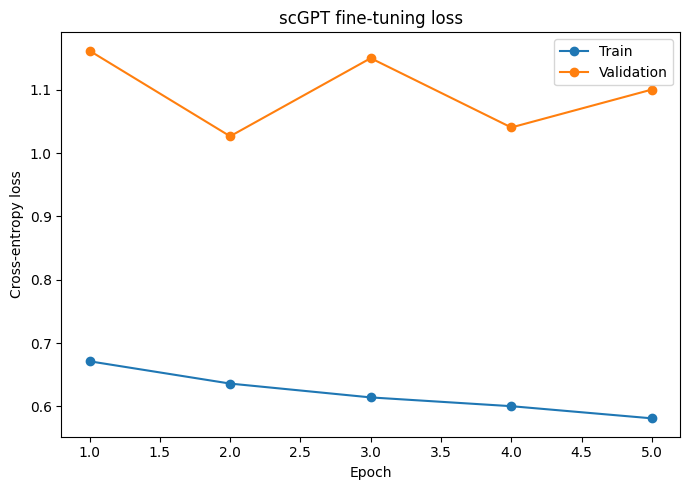

In [53]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")

ax.set_title(
    "scGPT fine-tuning loss"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "scgpt_training_loss.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

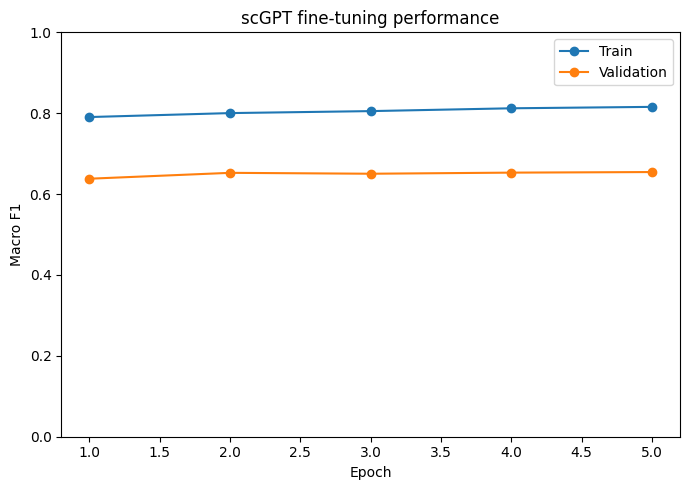

In [54]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    label="Train",
)

ax.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Validation",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")

ax.set_ylim(0, 1)

ax.set_title(
    "scGPT fine-tuning performance"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "scgpt_training_f1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [55]:
#Select best epoch
assert best_state is not None

model.load_state_dict(
    best_state
)

model = model.to(device)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation macro F1: "
    f"{best_val_f1:.4f}"
)

Best epoch: 5
Best validation macro F1: 0.6545


In [56]:
#save finetuned checkpoint
checkpoint = {

    "model_state_dict":
        best_state,

    "celltypes":
        celltypes,

    "type2id":
        type2id,

    "id2type":
        id2type,

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        best_val_f1,

    "max_seq_len":
        MAX_SEQ_LEN,

    "n_bins":
        N_BINS,

    "n_unfrozen_layers":
        N_UNFROZEN_LAYERS,

    "learning_rate":
        LEARNING_RATE,
}

torch.save(
    checkpoint,
    FINETUNE_DIR /
    "best_finetuned_model.pt",
)

print(
    "Saved:",
    FINETUNE_DIR /
    "best_finetuned_model.pt"
)

Saved: ../models/scGPT_finetuned/best_finetuned_model.pt


In [57]:
#evaluate on test donors
(
    test_predictions,
    test_labels,
    test_metrics,
) = evaluate_model(
    model,
    test_loader,
    criterion,
    device,
)

print(
    "FINE-TUNED scGPT — "
    "HELD-OUT DONOR TEST RESULTS"
)

print("=" * 50)

for metric, value in test_metrics.items():
    print(
        f"{metric:20s}: "
        f"{value:.4f}"
    )

FINE-TUNED scGPT — HELD-OUT DONOR TEST RESULTS
loss                : 0.6826
accuracy            : 0.9105
balanced_accuracy   : 0.7669
macro_f1            : 0.7738
weighted_f1         : 0.9084


In [59]:
#Converting ID's back into cell-types
true_celltypes = np.array([
    id2type[int(i)]
    for i in test_labels
])

predicted_celltypes = np.array([
    id2type[int(i)]
    for i in test_predictions
])

#add predictions to the anndata
adata_test.obs[
    "scgpt_prediction"
] = predicted_celltypes

#sneak peek
adata_test.obs[
    [
        "donor_id",
        "cell_type",
        "scgpt_prediction",
    ]
].head(20)

,donor_id,cell_type,scgpt_prediction
0,336,"CD4-positive, alpha-beta T cell","CD4-positive, alpha-beta T cell"
3,259,monocyte,monocyte
4,259,monocyte,monocyte
8,336,"CD8-positive, alpha-beta T cell","CD8-positive, alpha-beta T cell"
10,259,monocyte,monocyte
14,336,monocyte,monocyte
15,336,monocyte,monocyte
17,259,"CD8-positive, alpha-beta T cell","CD8-positive, alpha-beta T cell"
22,336,monocyte,monocyte
24,336,B cell,B cell


In [60]:
print(
    classification_report(
        true_celltypes,
        predicted_celltypes,
        labels=celltypes,
        zero_division=0,
    )
)

                                 precision    recall  f1-score   support

                       monocyte       0.94      0.97      0.96      7298
CD8-positive, alpha-beta T cell       0.96      0.83      0.89      3009
CD4-positive, alpha-beta T cell       0.82      0.93      0.87      1799
                         B cell       0.94      0.94      0.94      1884
            natural killer cell       0.59      0.87      0.71       408
              alpha-beta T cell       0.87      0.50      0.63       468
                 dendritic cell       0.78      0.83      0.81       235
                       platelet       0.70      0.27      0.39       116

                       accuracy                           0.91     15217
                      macro avg       0.83      0.77      0.77     15217
                   weighted avg       0.92      0.91      0.91     15217



In [61]:
#save report
report = classification_report(
    true_celltypes,
    predicted_celltypes,
    labels=celltypes,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report
).T

report_df

report_df.to_csv(
    RESULTS_DIR /
    "scgpt_classification_report.csv"
)

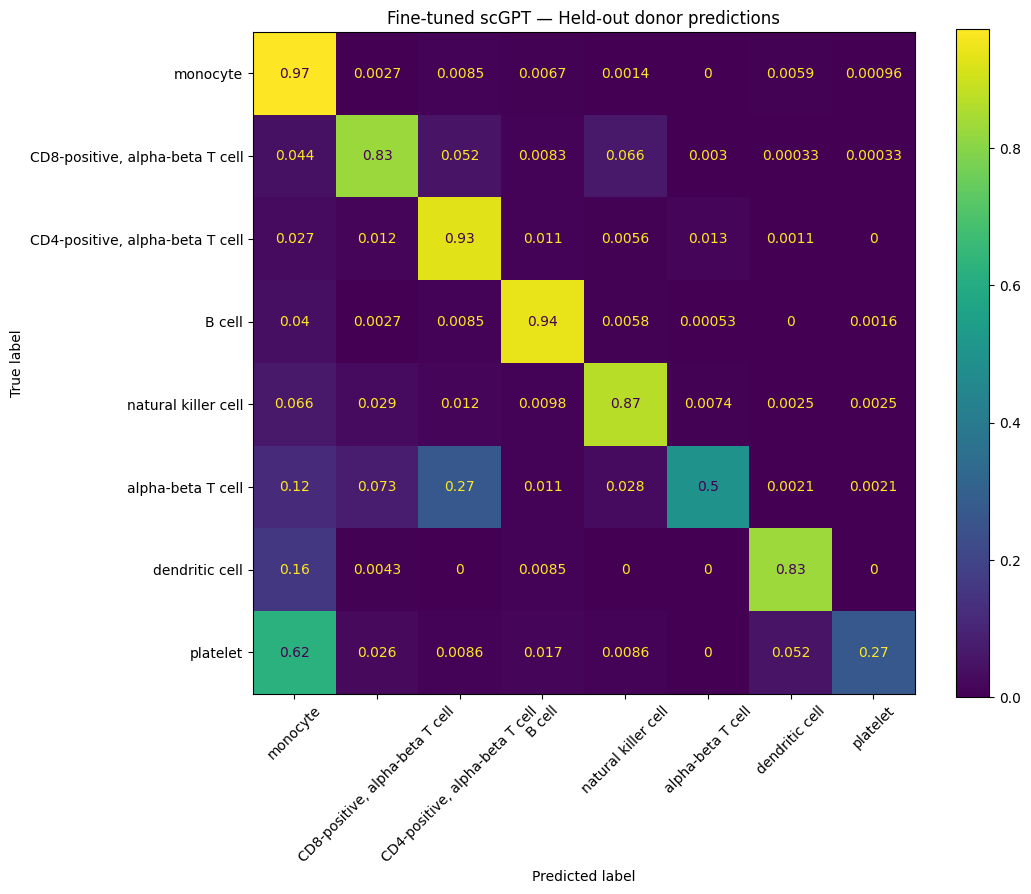

In [62]:
#confusion matrix
fig, ax = plt.subplots(
    figsize=(11, 9)
)

ConfusionMatrixDisplay.from_predictions(
    true_celltypes,
    predicted_celltypes,

    labels=celltypes,

    normalize="true",

    xticks_rotation=45,

    ax=ax,
)

ax.set_title(
    "Fine-tuned scGPT — "
    "Held-out donor predictions"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "scgpt_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [64]:
#individual cell predictions matrix
prediction_df = pd.DataFrame({

    "donor_id":
        adata_test.obs[
            "donor_id"
        ].astype(str).values,

    "true_cell_type":
        true_celltypes,

    "predicted_cell_type":
        predicted_celltypes,

    "correct":
        (
            true_celltypes
            == predicted_celltypes
        ),
})

prediction_df.to_csv(
    RESULTS_DIR /
    "scgpt_test_predictions.csv",
    index=False,
)

In [66]:
#saving scGPT metrics
scgpt_metrics_df = pd.DataFrame([
    {
        "model":
            "Fine-tuned scGPT",

        "split":
            "test",

        "accuracy":
            test_metrics["accuracy"],

        "balanced_accuracy":
            test_metrics[
                "balanced_accuracy"
            ],

        "macro_f1":
            test_metrics["macro_f1"],

        "weighted_f1":
            test_metrics[
                "weighted_f1"
            ],
    }
])

scgpt_metrics_df.to_csv(
    RESULTS_DIR /
    "scgpt_metrics.csv",
    index=False,
)

In [67]:
#comparing baseline to fine-tuned model
baseline_metrics = pd.read_csv(
    RESULTS_DIR /
    "baseline_metrics.csv"
)

baseline_test = (
    baseline_metrics[
        baseline_metrics["split"]
        == "test"
    ]
    .iloc[0]
)

comparison = pd.DataFrame([
    {
        "model":
            "Logistic Regression",

        "accuracy":
            baseline_test["accuracy"],

        "balanced_accuracy":
            baseline_test[
                "balanced_accuracy"
            ],

        "macro_f1":
            baseline_test["macro_f1"],

        "weighted_f1":
            baseline_test[
                "weighted_f1"
            ],
    },

    {
        "model":
            "Fine-tuned scGPT",

        "accuracy":
            test_metrics["accuracy"],

        "balanced_accuracy":
            test_metrics[
                "balanced_accuracy"
            ],

        "macro_f1":
            test_metrics["macro_f1"],

        "weighted_f1":
            test_metrics[
                "weighted_f1"
            ],
    },
])

comparison

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.860091,0.826449,0.707006,0.877978
1,Fine-tuned scGPT,0.910495,0.766920,0.773823,0.908364


In [68]:
#save the comparison
comparison.to_csv(
    RESULTS_DIR /
    "model_comparison.csv",
    index=False,
)

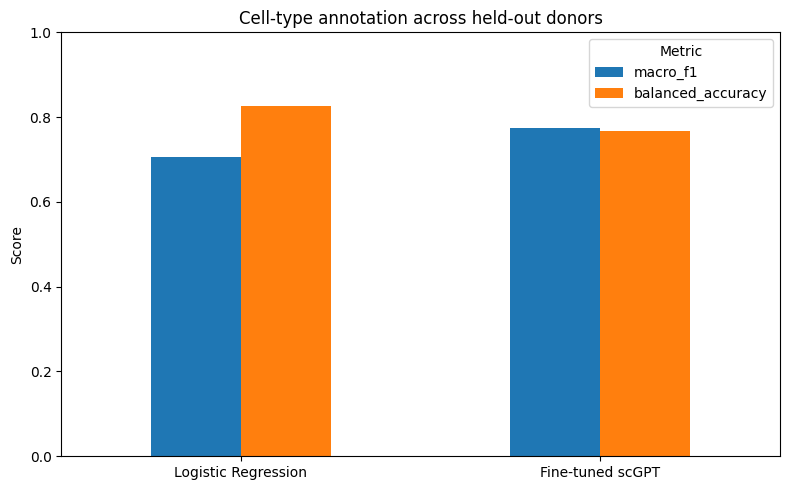

In [69]:
plot_df = (
    comparison
    .set_index("model")[
        [
            "macro_f1",
            "balanced_accuracy",
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("")

ax.set_title(
    "Cell-type annotation across "
    "held-out donors"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [70]:
print("=" * 60)
print("scGPT PROJECT SUMMARY")
print("=" * 60)

print(
    f"Training cells:       "
    f"{len(train_dataset):,}"
)

print(
    f"Validation cells:     "
    f"{len(val_dataset):,}"
)

print(
    f"Test cells:           "
    f"{len(test_dataset):,}"
)

print(
    f"Cell types:           "
    f"{num_types}"
)

print(
    f"scGPT genes:          "
    f"{len(gene_ids):,}"
)

print(
    f"Sequence length:      "
    f"{MAX_SEQ_LEN}"
)

print(
    f"Fine-tuned layers:    "
    f"{N_UNFROZEN_LAYERS}"
)

print(
    f"Best epoch:           "
    f"{best_epoch}"
)

print(
    f"Validation macro F1:  "
    f"{best_val_f1:.4f}"
)

print(
    f"Test accuracy:        "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test balanced acc.:   "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Test macro F1:        "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"Test weighted F1:     "
    f"{test_metrics['weighted_f1']:.4f}"
)

scGPT PROJECT SUMMARY
Training cells:       32,252
Validation cells:     10,866
Test cells:           15,217
Cell types:           8
scGPT genes:          1,468
Sequence length:      1024
Fine-tuned layers:    2
Best epoch:           5
Validation macro F1:  0.6545
Test accuracy:        0.9105
Test balanced acc.:   0.7669
Test macro F1:        0.7738
Test weighted F1:     0.9084
